# LangGraph Visualization - Multi-Agent Research Assistant

This notebook creates beautiful, colorful visualizations of the LangGraph multi-agent architecture.

**No API keys required** - This notebook only visualizes the graph structure, it doesn't make actual API calls.

## Graph Structure
- **Clarity Agent** → Validates query clarity
- **Research Agent** → Fetches company data (Tavily Search)
- **Validator Agent** → Validates research quality (with retry loop)
- **Synthesis Agent** → Generates final response
- **Clarification Node** → Human-in-the-loop interrupt

## 1. Install Required Dependencies

In [3]:
# Install visualization dependencies (uncomment if needed)
# !pip install langgraph langchain graphviz pillow
# !pip install ipython

## 2. Import Libraries and Build Graph

**Note**: This notebook automatically sets a dummy Tavily API key to prevent initialization errors. Graph visualization only needs the structure, not actual API calls.

In [4]:
import sys
import os

# Set dummy API key to prevent Tavily client initialization errors
# (Graph visualization doesn't need actual API calls)
if not os.getenv("TAVILY_API_KEY"):
    os.environ["TAVILY_API_KEY"] = "tvly-dummy-key-for-visualization"

# Add project root to path (works from any location)
project_root = os.path.dirname(os.path.abspath("__file__" if "__file__" in dir() else "."))
sys.path.insert(0, project_root)

from app.graph import build_graph
from IPython.display import Image, display, HTML
import base64

# Build the graph
graph = build_graph()
print("✅ Graph built successfully!")

✅ Graph built successfully!


## 3. Generate and Display Interactive Mermaid Diagram

This displays a colorful, clickable Mermaid diagram directly in the notebook.

In [5]:
# Generate Mermaid syntax
mermaid_code = graph.get_graph().draw_mermaid()

# Display with Mermaid.js rendering
html_template = f"""
<div class="mermaid">
{mermaid_code}
</div>

<script type="module">
  import mermaid from 'https://cdn.jsdelivr.net/npm/mermaid@10/dist/mermaid.esm.min.mjs';
  mermaid.initialize({{ startOnLoad: true, theme: 'default' }});
</script>

<style>
.mermaid {{
    text-align: center;
    margin: 20px 0;
}}
</style>
"""

display(HTML(html_template))
print("\n✅ Mermaid diagram rendered!")


✅ Mermaid diagram rendered!


## 4. Customize Mermaid Styling with Dark Theme

Apply a beautiful dark theme with custom colors for a more elegant visualization.

In [6]:
# Display with custom dark theme
html_dark_theme = f"""
<div class="mermaid">
{mermaid_code}
</div>

<script type="module">
  import mermaid from 'https://cdn.jsdelivr.net/npm/mermaid@10/dist/mermaid.esm.min.mjs';
  mermaid.initialize({{ 
    startOnLoad: true, 
    theme: 'dark',
    themeVariables: {{
      primaryColor: '#BB2528',
      primaryTextColor: '#fff',
      primaryBorderColor: '#7C0000',
      lineColor: '#F8B229',
      secondaryColor: '#006100',
      tertiaryColor: '#fff'
    }}
  }});
</script>

<style>
.mermaid {{
    text-align: center;
    margin: 20px 0;
    background: #1e1e1e;
    padding: 30px;
    border-radius: 10px;
}}
</style>
"""

display(HTML(html_dark_theme))
print("\n✅ Dark theme Mermaid diagram rendered!")


✅ Dark theme Mermaid diagram rendered!


## 5. High-Quality PNG Visualization with Graphviz

Generate a beautiful PNG image using LangGraph's built-in PNG rendering.

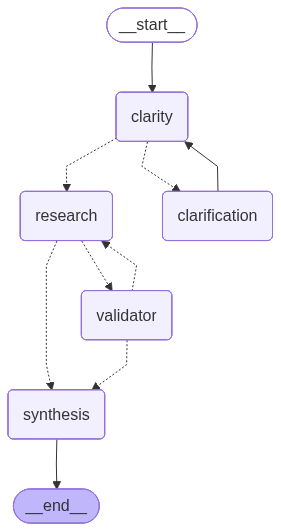


✅ PNG visualization rendered!


In [7]:
try:
    # Generate PNG visualization
    png_data = graph.get_graph().draw_mermaid_png()
    
    # Display the PNG
    display(Image(png_data))
    print("\n✅ PNG visualization rendered!")
    
except Exception as e:
    print(f"⚠️ PNG rendering requires graphviz to be installed on your system.")
    print(f"Error: {e}")
    print("\nTo fix:")
    print("1. Install Graphviz: https://graphviz.org/download/")
    print("2. Add it to your PATH")
    print("3. Restart Jupyter")

## 6. Save Visualizations to File

Export the graph visualizations for documentation or presentations.

In [8]:
# Save Mermaid code to file
with open("graph_visualization.mmd", "w") as f:
    f.write(mermaid_code)
print("✅ Saved Mermaid code to graph_visualization.mmd")

# Save PNG (if graphviz is available)
try:
    png_data = graph.get_graph().draw_mermaid_png()
    with open("graph_visualization.png", "wb") as f:
        f.write(png_data)
    print("✅ Saved PNG to graph_visualization.png")
except Exception as e:
    print(f"⚠️ Could not save PNG: {e}")

# Save HTML with interactive Mermaid
html_export = f"""
<!DOCTYPE html>
<html>
<head>
    <title>LangGraph Visualization</title>
    <script type="module">
      import mermaid from 'https://cdn.jsdelivr.net/npm/mermaid@10/dist/mermaid.esm.min.mjs';
      mermaid.initialize({{ startOnLoad: true, theme: 'forest' }});
    </script>
</head>
<body>
    <h1>Multi-Agent Research Assistant - LangGraph</h1>
    <div class="mermaid">
    {mermaid_code}
    </div>
</body>
</html>
"""

with open("graph_visualization.html", "w") as f:
    f.write(html_export)
print("✅ Saved interactive HTML to graph_visualization.html")

print("\n📁 Files created:")
print("  - graph_visualization.mmd (Mermaid source)")
print("  - graph_visualization.png (PNG image)")
print("  - graph_visualization.html (Interactive HTML)")

✅ Saved Mermaid code to graph_visualization.mmd
✅ Saved PNG to graph_visualization.png
✅ Saved interactive HTML to graph_visualization.html

📁 Files created:
  - graph_visualization.mmd (Mermaid source)
  - graph_visualization.png (PNG image)
  - graph_visualization.html (Interactive HTML)
